
# CNN Transfer Baseline — DeepFakeDetector

**Goal:** Fine-tune a pretrained CNN to classify images as **Real** vs **AI-generated** (deepfakes).  
This notebook is a **beginner-friendly, end-to-end baseline** that you can run locally or in Colab.

**Backbones supported:** `EfficientNet-B0` (default) and `ResNet-50` (toggle below).  
**Metrics:** Accuracy, F1, AUROC.  
**Extras:** Optional saliency map for interpretability, model checkpointing, and clear instructions.

> ✅ This file is the deliverable requested by the issue: `notebooks/cnn_transfer_baseline.ipynb`.



## 0. Setup

- You need Python 3.10+ recommended.
- If running the notebook locally, install dependencies with the cell below.
- If running in **Google Colab**, the cell will also work; GPU is recommended.

> Dataset (expected folder structure):
```
data/
  train/
    real/
    fake/
  val/
    real/
    fake/
```
- Each folder contains images (JPG/PNG). You may rename `fake` to `ai` if you like—just update the `CLASS_NAMES` below.


In [ ]:
!apt-get update -qq
!apt-get install -y -qq unzip
!unzip -q -o /content/datasets.zip -d /content
!find /content/datasets -maxdepth 3 -type d -print

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/content/datasets
/content/datasets/WildFake
/content/datasets/WildFake/train
/content/datasets/WildFake/train/fake
/content/datasets/WildFake/train/real
/content/datasets/WildFake/test
/content/datasets/WildFake/test/fake
/content/datasets/WildFake/test/real
/content/datasets/OpenFake
/content/datasets/OpenFake/train
/content/datasets/OpenFake/train/fake
/content/datasets/OpenFake/train/real
/content/datasets/OpenFake/test
/content/datasets/OpenFake/test/fake
/content/datasets/OpenFake/test/real


In [ ]:

# If you are on Colab or a fresh environment, uncomment and run:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install scikit-learn matplotlib tqdm pillow captum


In [ ]:

import os, time, copy, math
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ---- Beginner-friendly switches ----
DATA_DIR = Path("data")   # change if your dataset lives elsewhere
USE_MODEL = "efficientnet_b0"  # options: "efficientnet_b0", "resnet50"
FREEZE_BACKBONE = True         # freeze feature extractor first
UNFREEZE_EPOCH = 3             # unfreeze from this epoch (set None to keep frozen)
NUM_EPOCHS = 5                 # increase for real training
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

# Class name mapping (folder names under train/ and val/). Adjust if your folder uses "ai" instead of "fake".
CLASS_NAMES = ["real", "fake"]

# Where to save best checkpoints & logs
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


Using device: cuda



## 1. Data Loading and Augmentations

- We use `ImageFolder` so the folder names define classes.
- Basic augmentations help generalization.


In [ ]:
# ----- Dirs, tfms, datasets, loaders -----
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IM_SIZE = 224                     # matches EfficientNet-B0 and ResNet-50 defaults
BATCH_SIZE = 32
NUM_WORKERS = 2                   # set 0 if you see DataLoader issues on your setup
CLASS_NAMES = ["real", "fake"]    # expected subfolder names

# Point to OpenFake and tell the code that "test" is our validation split
DATA_DIR = Path("datasets/OpenFake")
TRAIN_SPLIT = "train"
VAL_SPLIT   = "test"              # you currently have "test", not "val"

train_dir = DATA_DIR / TRAIN_SPLIT
val_dir   = DATA_DIR / VAL_SPLIT

assert train_dir.exists(), f"Missing folder: {train_dir}"
assert (train_dir / "real").exists() and (train_dir / "fake").exists(), \
    f"Train split must contain subfolders {CLASS_NAMES}"
assert val_dir.exists(), f"Missing folder: {val_dir}"
assert (val_dir / "real").exists() and (val_dir / "fake").exists(), \
    f"Val split must contain subfolders {CLASS_NAMES}"

# Basic augmentations for train, eval-safe for val
train_tfms = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Build datasets
train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=val_tfms)

idx_to_name = train_ds.classes              # e.g. ['fake','real']
name_to_idx = train_ds.class_to_idx         # e.g. {'fake':0, 'real':1}
FAKE = name_to_idx['fake']

print("Detected classes in train_ds:", train_ds.classes)
# assert train_ds.classes == CLASS_NAMES, \
    # f"Expected classes {CLASS_NAMES}, got {train_ds.classes}"

# DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"Train images: {len(train_ds)}  |  Val images: {len(val_ds)}")


Detected classes in train_ds: ['fake', 'real']
Train images: 2426  |  Val images: 476



## 2. Build the Model (Transfer Learning)

Pick a pretrained backbone and replace the classification head with a 2‑class head.


In [ ]:

def build_model(name: str, num_classes: int = 2, freeze_backbone: bool = True):
    if name == "efficientnet_b0":
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        feature_modules = [model.features]
    elif name == "resnet50":
        from torchvision.models import resnet50, ResNet50_Weights
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        feature_modules = [model.conv1, model.layer1, model.layer2, model.layer3, model.layer4]
    else:
        raise ValueError("Unknown model: " + name)

    if freeze_backbone:
        for m in feature_modules:
            for p in m.parameters():
                p.requires_grad = False

    return model

model = build_model(USE_MODEL, num_classes=2, freeze_backbone=FREEZE_BACKBONE).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR, weight_decay=WEIGHT_DECAY)
print(model.__class__.__name__, "built. Trainable params:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))


EfficientNet built. Trainable params: 2562



## 3. Training & Validation Loop

- Trains with the head (and optionally unfreezes the backbone later).
- Tracks Accuracy, F1, and AUROC.
- Saves the **best** model checkpoint by AUROC.


In [ ]:
def run_epoch(model, loader, fake_idx, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    all_logits, all_y = [], []
    running_loss = 0.0

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            logits = model(imgs)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        all_logits.append(logits.detach().cpu())
        all_y.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits)
    all_y = torch.cat(all_y).numpy()

    # use the true index for "fake"
    probs = torch.softmax(all_logits, dim=1)[:, fake_idx].numpy()
    y_fake = (all_y == fake_idx).astype(int)          # make "fake" the positive class
    preds  = (probs >= 0.5).astype(int)

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_fake, preds)
    f1  = f1_score(y_fake, preds, zero_division=0)
    try:
        auroc = roc_auc_score(y_fake, probs)
    except ValueError:
        auroc = float("nan")
    return epoch_loss, acc, f1, auroc

best_auroc = -1.0
best_path = ARTIFACTS_DIR / f"best_{USE_MODEL}.pt"
history = {"train": [], "val": []}

for epoch in range(1, NUM_EPOCHS+1):
    if UNFREEZE_EPOCH is not None and epoch == UNFREEZE_EPOCH:
        print(f"Unfreezing backbone at epoch {epoch}...")
        for p in model.parameters():
            p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR/10, weight_decay=WEIGHT_DECAY)

    t0 = time.time()
    tr_loss, tr_acc, tr_f1, tr_auroc = run_epoch(model, train_loader, FAKE, optimizer)
    va_loss, va_acc, va_f1, va_auroc = run_epoch(model, val_loader,   FAKE, optimizer=None)
    dt = time.time() - t0

    history["train"].append((tr_loss, tr_acc, tr_f1, tr_auroc))
    history["val"].append((va_loss, va_acc, va_f1, va_auroc))

    print(f"Epoch {epoch:02d} | {dt:.1f}s "
          f"| train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} auroc {tr_auroc:.3f} "
          f"| val loss {va_loss:.4f} acc {va_acc:.3f} f1 {va_f1:.3f} auroc {va_auroc:.3f}")

    if not math.isnan(va_auroc) and va_auroc > best_auroc:
        best_auroc = va_auroc
        torch.save({"model_state": model.state_dict(),
                    "model_name": USE_MODEL,
                    "class_names": train_ds.classes}, best_path)
        print(f"✅ Saved new best checkpoint to {best_path} (val AUROC={best_auroc:.3f})")


Epoch 01 | 22.1s | train loss 0.6268 acc 0.652 f1 0.663 auroc 0.705 | val loss 0.5844 acc 0.693 f1 0.706 auroc 0.764
✅ Saved new best checkpoint to artifacts/best_efficientnet_b0.pt (val AUROC=0.764)
Epoch 02 | 22.3s | train loss 0.5521 acc 0.719 f1 0.727 auroc 0.796 | val loss 0.5645 acc 0.710 f1 0.730 auroc 0.779
✅ Saved new best checkpoint to artifacts/best_efficientnet_b0.pt (val AUROC=0.779)
Unfreezing backbone at epoch 3...
Epoch 03 | 22.2s | train loss 0.4705 acc 0.768 f1 0.775 auroc 0.857 | val loss 0.4298 acc 0.807 f1 0.821 auroc 0.883
✅ Saved new best checkpoint to artifacts/best_efficientnet_b0.pt (val AUROC=0.883)
Epoch 04 | 22.4s | train loss 0.2762 acc 0.884 f1 0.886 auroc 0.959 | val loss 0.4137 acc 0.815 f1 0.821 auroc 0.896
✅ Saved new best checkpoint to artifacts/best_efficientnet_b0.pt (val AUROC=0.896)
Epoch 05 | 22.2s | train loss 0.1860 acc 0.932 f1 0.932 auroc 0.983 | val loss 0.4305 acc 0.826 f1 0.836 auroc 0.900
✅ Saved new best checkpoint to artifacts/best_eff


## 4. Curves


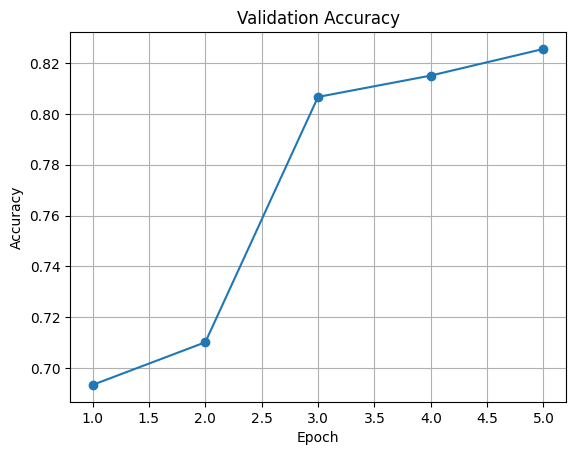

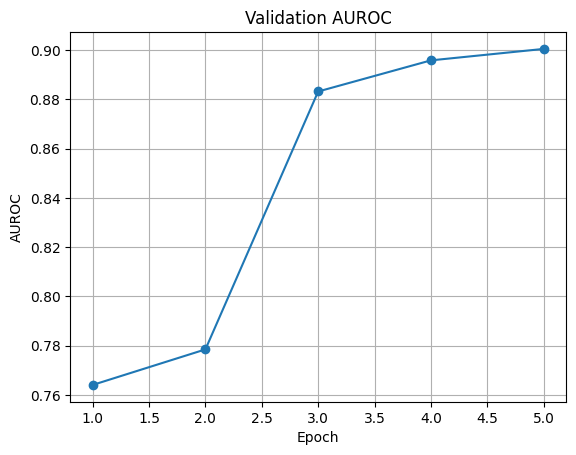

In [ ]:

# Plot Accuracy & AUROC (validation)
val_acc = [x[1] for x in history["val"]]
val_auroc = [x[3] for x in history["val"]]

plt.figure()
plt.plot(range(1, len(val_acc)+1), val_acc, marker='o')
plt.title("Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.grid(True)
plt.show()

plt.figure()
plt.plot(range(1, len(val_auroc)+1), val_auroc, marker='o')
plt.title("Validation AUROC")
plt.xlabel("Epoch"); plt.ylabel("AUROC"); plt.grid(True)
plt.show()



## 5. Optional: Simple Saliency Map (Captum)

This helps **explain** which pixels most influence the prediction.  
Run after training. Provide a path to a single image.


Fake example: datasets/OpenFake/test/fake/test_0000000.jpg


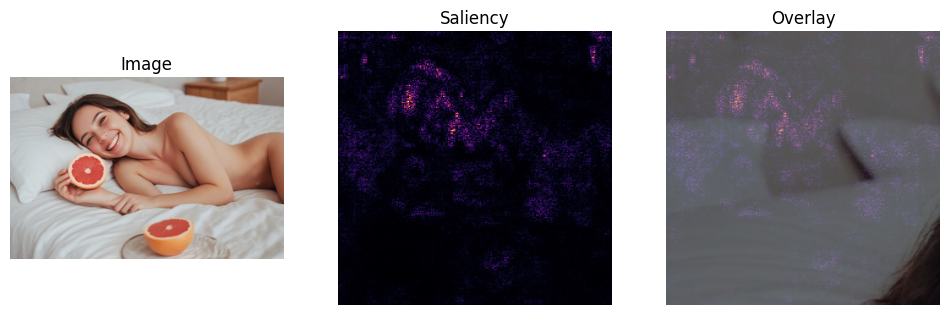

Real example: datasets/OpenFake/test/real/test_0000002.jpg


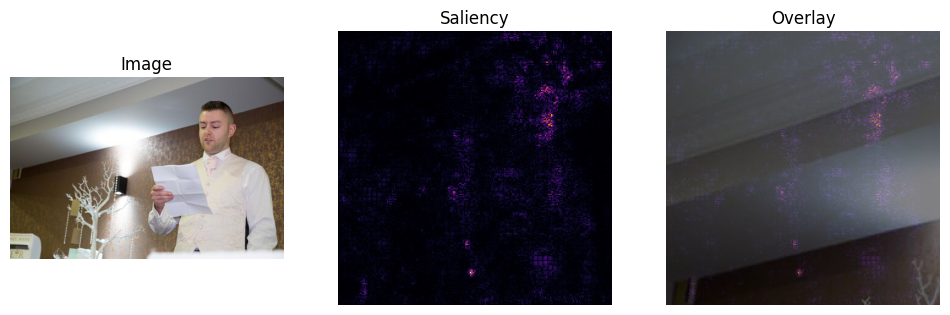

In [ ]:
# 1) Ensure Captum is available
try:
    from captum.attr import Saliency
except Exception:
    %pip -q install captum
    from captum.attr import Saliency

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 2) Make sure we have a trained model in scope
try:
    _ = model.state_dict()
except NameError:
    # load the best checkpoint your notebook saved
    ckpt = torch.load(str(best_path), map_location=DEVICE)
    model = build_model(ckpt["model_name"], num_classes=len(ckpt["class_names"]), freeze_backbone=False).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])

model.eval()

# 3) Helper to compute and show saliency with gradients enabled
def show_saliency(img_path):
    assert os.path.exists(img_path), f"Not found: {img_path}"
    from torchvision import transforms

    pil = Image.open(img_path).convert("RGB")
    x = val_tfms(pil).unsqueeze(0).to(DEVICE)
    x.requires_grad_(True)

    # make sure gradients are on
    torch.set_grad_enabled(True)
    model.zero_grad()

    logits = model(x)
    target_class = int(logits.argmax(dim=1).item())

    sal = Saliency(model)
    attributions = sal.attribute(x, target=target_class)      # [1,3,H,W]
    attr = attributions.abs().detach().squeeze().mean(0).cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(pil); ax[0].set_title("Image"); ax[0].axis("off")
    ax[1].imshow(attr, cmap="inferno"); ax[1].set_title("Saliency"); ax[1].axis("off")
    ax[2].imshow(pil); ax[2].imshow(attr, cmap="inferno", alpha=0.5); ax[2].set_title("Overlay"); ax[2].axis("off")
    plt.show()

# 4) Pick one fake and one real from your current val set and run it
# ImageFolder exposes file paths in .samples -> list of (path, class_idx)
from pathlib import Path

idx_to_name = val_ds.classes               # e.g. ['fake','real']
name_to_idx = val_ds.class_to_idx          # e.g. {'fake':0,'real':1}
FAKE = name_to_idx['fake']
REAL = name_to_idx['real']

fake_path = next(p for p, y in val_ds.samples if y == FAKE)
real_path = next(p for p, y in val_ds.samples if y == REAL)

print("Fake example:", fake_path)
show_saliency(fake_path)

print("Real example:", real_path)
show_saliency(real_path)



## 6. Inference Helper


In [40]:
def load_best(model_path=best_path):
    ckpt = torch.load(model_path, map_location=DEVICE)
    model = build_model(
        ckpt["model_name"],
        num_classes=len(ckpt["class_names"]),
        freeze_backbone=False
    )
    model.load_state_dict(ckpt["model_state"])
    model.to(DEVICE).eval()
    return model, ckpt["class_names"]  # return the saved names

@torch.inference_mode()
def predict_image(img_path, model=None, class_names=None, thresh=0.5):
    from PIL import Image

    # load model and class names from the checkpoint if not provided
    if model is None or class_names is None:
        model, class_names = load_best(best_path)

    # map names to indices from the same source used to train
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    assert "fake" in name_to_idx and "real" in name_to_idx, f"class_names missing expected labels: {class_names}"
    FAKE = name_to_idx["fake"]
    REAL = name_to_idx["real"]

    # preprocess and predict
    pil = Image.open(img_path).convert("RGB")
    x = val_tfms(pil).unsqueeze(0).to(DEVICE)
    logits = model(x)
    probs  = torch.softmax(logits, dim=1)[0]

    prob_fake = probs[FAKE].item()
    pred_idx  = FAKE if prob_fake >= thresh else REAL
    pred_name = class_names[pred_idx]

    return {
        "prob_fake": prob_fake,
        "pred_idx": int(pred_idx),
        "label": pred_name,
        "class_names": class_names
    }

from pathlib import Path
name_to_idx = val_ds.class_to_idx
FAKE = name_to_idx["fake"]
REAL = name_to_idx["real"]

fake_path = next(p for p, y in val_ds.samples if y == FAKE)
real_path = next(p for p, y in val_ds.samples if y == REAL)

print("Fake example:", fake_path)
print(predict_image(fake_path))

print("Real example:", real_path)
print(predict_image(real_path))



Fake example: datasets/OpenFake/test/fake/test_0000000.jpg
{'prob_fake': 0.9924728870391846, 'pred_idx': 0, 'label': 'fake', 'class_names': ['fake', 'real']}
Real example: datasets/OpenFake/test/real/test_0000002.jpg
{'prob_fake': 0.0017101704142987728, 'pred_idx': 1, 'label': 'real', 'class_names': ['fake', 'real']}



## 7. Record Results (Fill After Training)

- **Backbone:** EfficientNet-B0 or ResNet-50  
- **Freeze > Unfreeze epoch:** e.g., 1–2 epochs frozen, unfreeze at 3  
- **Val Accuracy:** …  
- **Val F1:** …  
- **Val AUROC:** …  
- **Observations:** … (e.g., overfitting signs, which backbone worked better, any class imbalance tweaks)

> Tip: If your dataset is imbalanced, consider using `WeightedRandomSampler` or class weights in `CrossEntropyLoss`.


In [41]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model, class_names = load_best(best_path)
name_to_idx = {n:i for i,n in enumerate(class_names)}
FAKE = name_to_idx['fake']

probs, y_true = [], []
for path, y in val_ds.samples:
    y_true.append(1 if y == FAKE else 0)  # 1=fake, 0=real
    probs.append(predict_image(path, model=model, class_names=class_names)['prob_fake'])

probs  = np.array(probs)
y_true = np.array(y_true)
preds  = (probs >= 0.5).astype(int)

acc  = accuracy_score(y_true, preds)
f1   = f1_score(y_true, preds)
try:
    auroc = roc_auc_score(y_true, probs)
except ValueError:
    auroc = float("nan")

print(f"VAL  acc={acc:.3f}  f1={f1:.3f}  auroc={auroc:.3f}")


VAL  acc=0.826  f1=0.836  auroc=0.900



## 8. (Optional) Write a `requirements.txt`

Run this cell once to generate a minimal `requirements.txt` alongside artifacts.


In [ ]:

req = '''torch
torchvision
torchaudio
scikit-learn
matplotlib
tqdm
pillow
captum
'''
with open('requirements.txt', 'w') as f:
    f.write(req.strip() + "\n")
print("Wrote requirements.txt")


Wrote requirements.txt
